# Importing libs

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Reading CSV

In [2]:
df = pd.read_csv('data/train.csv')
df.head()

print(df.shape)             
print(df.dtypes.value_counts()) 
print(df["SalePrice"].describe()) 
print(df.isnull().sum().sort_values(ascending=False).head(10))

(1460, 81)
str        43
int64      35
float64     3
Name: count, dtype: int64
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


# Feature Selection

In [3]:
df_numeric = df.select_dtypes(include=[np.number])

threshold = 0.05 * len(df_numeric)
df_clean = df_numeric.dropna(axis=1, thresh=len(df_numeric) - threshold)

df_clean = df_clean.dropna(axis=0)

print(f"Shape after cleaning: {df_clean.shape}")
print(f"Remaining features: {df_clean.columns.tolist()}")

Shape after cleaning: (1452, 36)
Remaining features: ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [4]:
y = df_clean['SalePrice'].values
X = df_clean.drop(columns=['SalePrice']).values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


X shape: (1452, 35)
y shape: (1452,)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def z_score_normalize(X_train, X_val):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma = np.where(sigma == 0, 1, sigma)
    
    X_train_n = (X_train - mu)/sigma
    X_val_n = (X_val - mu)/sigma
    
    return X_train_n, X_val_n, mu, sigma

X_train_n, X_val_n, mu, sigma = z_score_normalize(X_train, X_val)
y_mu = y_train.mean()
y_sigma = y_train.std()
y_train_n = (y_train - y_mu) / y_sigma
y_val_n = (y_val - y_mu) / y_sigma

## Adding bias column

In [6]:
def add_bias(X):
    m = X.shape[0]
    return np.c_[np.ones(m), X]
    
X_train_b = add_bias(X_train_n)
X_val_b = add_bias(X_val_n)



In [7]:
def predict(X, theta):
    """f_w,b(X) = X @ w + b"""
    return X @ theta

def compute_cost(X, y, theta):
    m = X.shape[0]
    return (1 / (2 * m)) * np.sum((predict(X, theta) - y)** 2)

def compute_gradient(X, y, theta):
    m = X.shape[0]
    residuals = predict(X, theta) - y
    return (1 / m) * X.T @ residuals

def gradient_descent(X, y, alpha, num_iters):
    theta = np.zeros(X.shape[1])
    cost_history = []
    for _ in range(num_iters):
        theta = theta - alpha * compute_gradient(X, y, theta)
        cost_history.append(compute_cost(X, y, theta))
        
    return theta, cost_history

# Training and Tuning

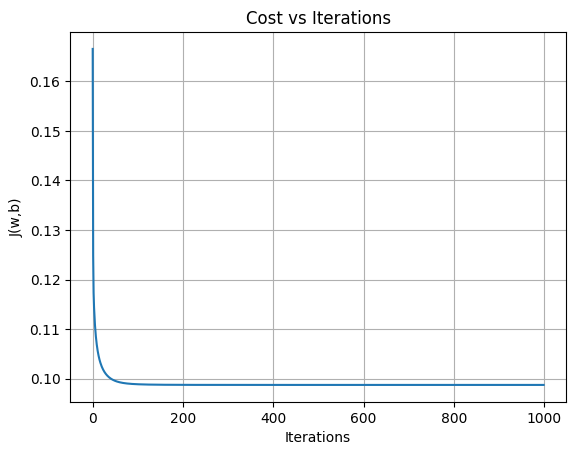

In [8]:

theta, cost_history = gradient_descent(X_train_b, y_train_n, alpha=0.1, num_iters=1000)

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel('J(w,b)')
plt.title('Cost vs Iterations')
plt.grid(True)
plt.savefig('outputs/manual_cost_curve.png')
plt.show()

# Evaluation

In [9]:
def rmse(y_true, y_pred):
    return  np.sqrt(np.mean((y_pred - y_true) ** 2))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

y_train_pred = predict(X_train_b, theta) * y_sigma + y_mu
y_val_pred = predict(X_val_b, theta) * y_sigma + y_mu
print(f"Train RMSE: ${rmse(y_train, y_train_pred):,.0f}")
print(f"Val   RMSE: ${rmse(y_val,   y_val_pred):,.0f}")
print(f"Train R²:   {r_squared(y_train, y_train_pred):.4f}")
print(f"Val   R²:   {r_squared(y_val,   y_val_pred):.4f}")

Train RMSE: $35,341
Val   RMSE: $30,503
Train R²:   0.8026
Val   R²:   0.8476
